In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("electricity_cost_dataset.csv")
df.head()

,site area,structure type,water consumption,recycling rate,utilisation rate,air qality index,issue reolution time,resident count,electricity cost
0,1360,Mixed-use,2519.0,69,52,188,1,72,1420.0
1,4272,Mixed-use,2324.0,50,76,165,65,261,3298.0
2,3592,Mixed-use,2701.0,20,94,198,39,117,3115.0
3,966,Residential,1000.0,13,60,74,3,35,1575.0
4,4926,Residential,5990.0,23,65,32,57,185,4301.0


In [5]:
df.columns = df.columns.str.lower().str.replace(" ", "_")
df.head()

,site_area,structure_type,water_consumption,recycling_rate,utilisation_rate,air_qality_index,issue_reolution_time,resident_count,electricity_cost
0,1360,Mixed-use,2519.0,69,52,188,1,72,1420.0
1,4272,Mixed-use,2324.0,50,76,165,65,261,3298.0
2,3592,Mixed-use,2701.0,20,94,198,39,117,3115.0
3,966,Residential,1000.0,13,60,74,3,35,1575.0
4,4926,Residential,5990.0,23,65,32,57,185,4301.0


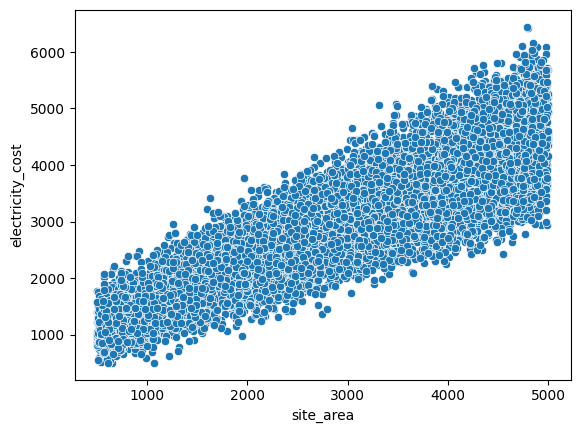

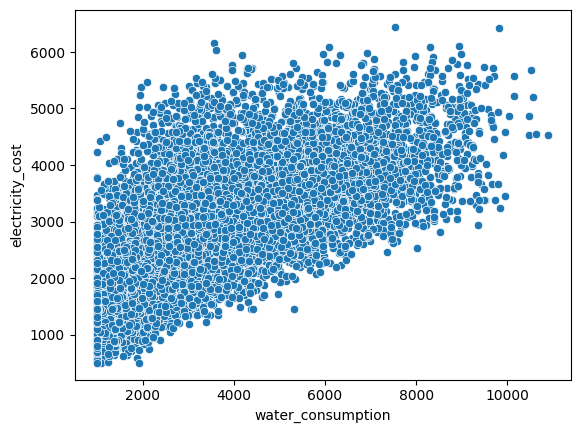

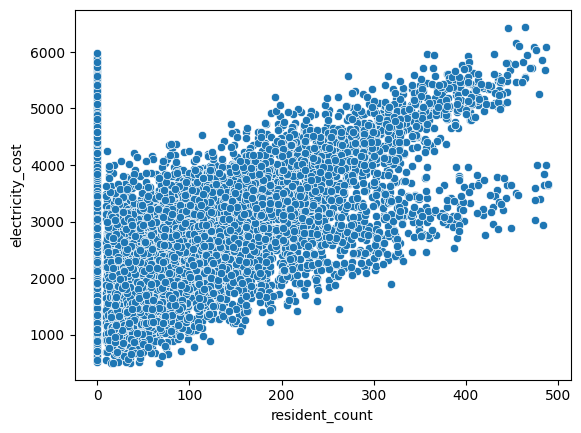

In [6]:
sns.scatterplot(x=df["site_area"], y=df["electricity_cost"])
plt.show()

sns.scatterplot(x=df["water_consumption"], y=df["electricity_cost"])
plt.show()

sns.scatterplot(x=df["resident_count"], y=df["electricity_cost"])
plt.show()

In [7]:
df.corr(numeric_only=True)["electricity_cost"].sort_values(ascending=False)

,electricity_cost
electricity_cost,1.000000
site_area,0.874376
water_consumption,0.698775
resident_count,0.361609
utilisation_rate,0.207215
issue_reolution_time,0.042325
air_qality_index,0.017376
recycling_rate,-0.012536


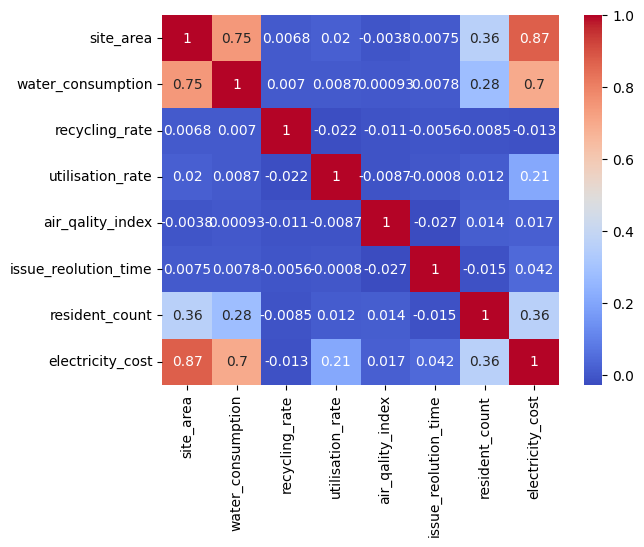

In [8]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [11]:

df = df.drop([
    "recycling_rate"
], axis=1, errors="ignore")

In [13]:
df = pd.get_dummies(df, columns=["structure_type"])
df.head()

,site_area,water_consumption,utilisation_rate,resident_count,electricity_cost,structure_type_Commercial,structure_type_Industrial,structure_type_Mixed-use,structure_type_Residential
0,1360,2519.0,52,72,1420.0,False,False,True,False
1,4272,2324.0,76,261,3298.0,False,False,True,False
2,3592,2701.0,94,117,3115.0,False,False,True,False
3,966,1000.0,60,35,1575.0,False,False,False,True
4,4926,5990.0,65,185,4301.0,False,False,False,True


In [15]:
X = df.drop("electricity_cost", axis=1)
y = df["electricity_cost"]

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [20]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R2 Score: 0.9586676288764443
MAE: 180.67164000000002
RMSE: 227.07233809053008


In [22]:
import joblib

joblib.dump(model, "electricity_model.pkl")

['electricity_model.pkl']